In [ ]:
# Alternative: Ultra-minimalist confusion matrix (if you want even cleaner look)
def plot_minimal_confusion_matrix(y_true, y_pred, title, figsize=(10, 8)):
    """
    Ultra-clean confusion matrix with minimal styling - only essential info.
    """
    # Round and convert
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    scores = np.arange(0, 10.5, 0.5)
    scores_str = [f"{x:.1f}" for x in scores]
    
    cm = confusion_matrix(y_true_str, y_pred_str, labels=scores_str)
    
    # Create minimal figure
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Use very light blue-gray colormap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', 
                   vmin=0, vmax=cm.max()*0.7, alpha=0.7)
    
    # Minimal ticks - show fewer labels
    tick_positions = np.arange(0, len(scores), 2)  # Every other score
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels([scores[i] for i in tick_positions], fontsize=10)
    ax.set_yticklabels([scores[i] for i in tick_positions], fontsize=10)
    
    # Add numbers only where count > 0
    for i in range(len(scores)):
        for j in range(len(scores)):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                       color='white' if cm[i, j] > cm.max()*0.4 else 'black',
                       fontsize=9, fontweight='bold')
    
    # Minimal labels
    ax.set_ylabel('Ground Truth', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Remove spines for ultra-clean look
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    return fig

print("✨ Choose your preferred style:")
print("- plot_confusion_matrix() → Clean with light colors, counts only")
print("- plot_minimal_confusion_matrix() → Ultra-minimal, super clean")
print()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Load your CSV file
csv_path = "/home/user01/aiotlab/sondinh/Flamingo/audio-flamingo/audio_flamingo_2/train/test_result_corrected_full.csv"  # Change this to your CSV path
df = pd.read_csv(csv_path)

print(f"Dataset loaded: {len(df)} samples")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded: 12325 samples

Columns: ['Audio File', 'Prompt', 'Ground Truth', 'Prediction', 'GT Grammar', 'GT Vocab', 'GT Discourse', 'GT Total', 'Pred Grammar', 'Pred Vocab', 'Pred Discourse', 'Pred Total']

First few rows:


,Audio File,Prompt,Ground Truth,Prediction,GT Grammar,GT Vocab,GT Discourse,GT Total,Pred Grammar,Pred Vocab,Pred Discourse,Pred Total
0,/home/user06/data/Speaking_VSTEP/SPEAKING/11. ...,"you are an expert english-speaking examiner, s...",grammar: 4.0/10\nvocabulary: 4.0/10\ndiscourse...,grammar: 7.0/10\nvocabulary: 4.0/10\ndiscourse...,4.0,4.0,4.0,4.000000,7.0,4.0,4.0,5.000000
1,/home/user06/data/Speaking_VSTEP/SPEAKING/42. ...,"you are an expert english-speaking examiner, s...",grammar: 4.5/10\nvocabulary: 5.0/10\ndiscourse...,grammar: 7.0/10\nvocabulary: 4.0/10\ndiscourse...,4.5,5.0,5.0,4.833333,7.0,4.0,5.0,5.333333
2,/home/user06/data/Speaking_VSTEP/SPEAKING/28. ...,"you are an expert english-speaking examiner, s...",grammar: 5.0/10\nvocabulary: 4.0/10\ndiscourse...,grammar: 5.0/10\nvocabulary: 5.5/10\ndiscourse...,5.0,4.0,4.0,4.333333,5.0,5.5,4.0,4.833333
3,/home/user06/data/Speaking_VSTEP/DATA_Vocal/CD...,"you are an expert english-speaking examiner, s...",grammar: 7.0/10\nvocabulary: 7.0/10\ndiscourse...,grammar: 7.0/10\nvocabulary: 7.0/10\ndiscourse...,7.0,7.0,6.0,6.666667,7.0,7.0,8.0,7.333333
4,/home/user06/data/Speaking_VSTEP/SPEAKING/24. ...,"you are an expert english-speaking examiner, s...",grammar: 7.0/10\nvocabulary: 7.0/10\ndiscourse...,grammar: 7.0/10\nvocabulary: 7.0/10\ndiscourse...,7.0,7.0,7.0,7.000000,7.0,7.0,8.0,7.333333


In [3]:
# Calculate absolute errors for each category
df['grammar_error'] = abs(df['Pred Grammar'] - df['GT Grammar'])
df['vocab_error'] = abs(df['Pred Vocab'] - df['GT Vocab'])
df['discourse_error'] = abs(df['Pred Discourse'] - df['GT Discourse'])
df['total_error'] = abs(df['Pred Total'] - df['GT Total'])

# Remove rows with NaN values for analysis
df_clean = df.dropna(subset=['GT Grammar', 'GT Vocab', 'GT Discourse', 'GT Total',
                              'Pred Grammar', 'Pred Vocab', 'Pred Discourse', 'Pred Total'])

print(f"Clean dataset: {len(df_clean)} samples (removed {len(df) - len(df_clean)} NaN rows)")
print("\nError Statistics:")
print(f"Grammar MAE: {df_clean['grammar_error'].mean():.4f}")
print(f"Vocabulary MAE: {df_clean['vocab_error'].mean():.4f}")
print(f"Discourse MAE: {df_clean['discourse_error'].mean():.4f}")
print(f"Total MAE: {df_clean['total_error'].mean():.4f}")

Clean dataset: 12325 samples (removed 0 NaN rows)

Error Statistics:
Grammar MAE: 1.2810
Vocabulary MAE: 0.2690
Discourse MAE: 0.4213
Total MAE: 0.4936


In [4]:
def calculate_error_distribution(errors):
    """Calculate percentage of samples in each error range."""
    total = len(errors)
    exact = (errors == 0).sum()
    half = ((errors > 0) & (errors <= 0.5)).sum()
    one = ((errors > 0.5) & (errors <= 1.0)).sum()
    above_one = (errors > 1.0).sum()
    
    return {
        'Exact (0)': f"{exact} ({exact/total*100:.1f}%)",
        'Small (0-0.5]': f"{half} ({half/total*100:.1f}%)",
        'Medium (0.5-1.0]': f"{one} ({one/total*100:.1f}%)",
        'Large (>1.0)': f"{above_one} ({above_one/total*100:.1f}%)"
    }

# Create error distribution table
error_dist = pd.DataFrame({
    'Grammar': calculate_error_distribution(df_clean['grammar_error']),
    'Vocabulary': calculate_error_distribution(df_clean['vocab_error']),
    'Discourse': calculate_error_distribution(df_clean['discourse_error']),
    'Total': calculate_error_distribution(df_clean['total_error'])
})

print("="*80)
print("ERROR DISTRIBUTION BY CATEGORY")
print("="*80)
print(error_dist)
print("="*80)

ERROR DISTRIBUTION BY CATEGORY
                       Grammar    Vocabulary     Discourse         Total
Exact (0)         2025 (16.4%)  8441 (68.5%)  6307 (51.2%)  1470 (11.9%)
Small (0-0.5]     1460 (11.8%)  1560 (12.7%)  2229 (18.1%)  6083 (49.4%)
Medium (0.5-1.0]  3776 (30.6%)  1905 (15.5%)  3290 (26.7%)  3947 (32.0%)
Large (>1.0)      5064 (41.1%)    419 (3.4%)    499 (4.0%)    825 (6.7%)


🎨 Available color styles:
1. 'soft' - Light Purple (Recommended)
2. 'ocean' - Light Blue
3. 'mint' - Light Green
4. 'sunset' - Light Orange
5. 'minimal' - Grayscale

📊 Grammar Confusion Matrix


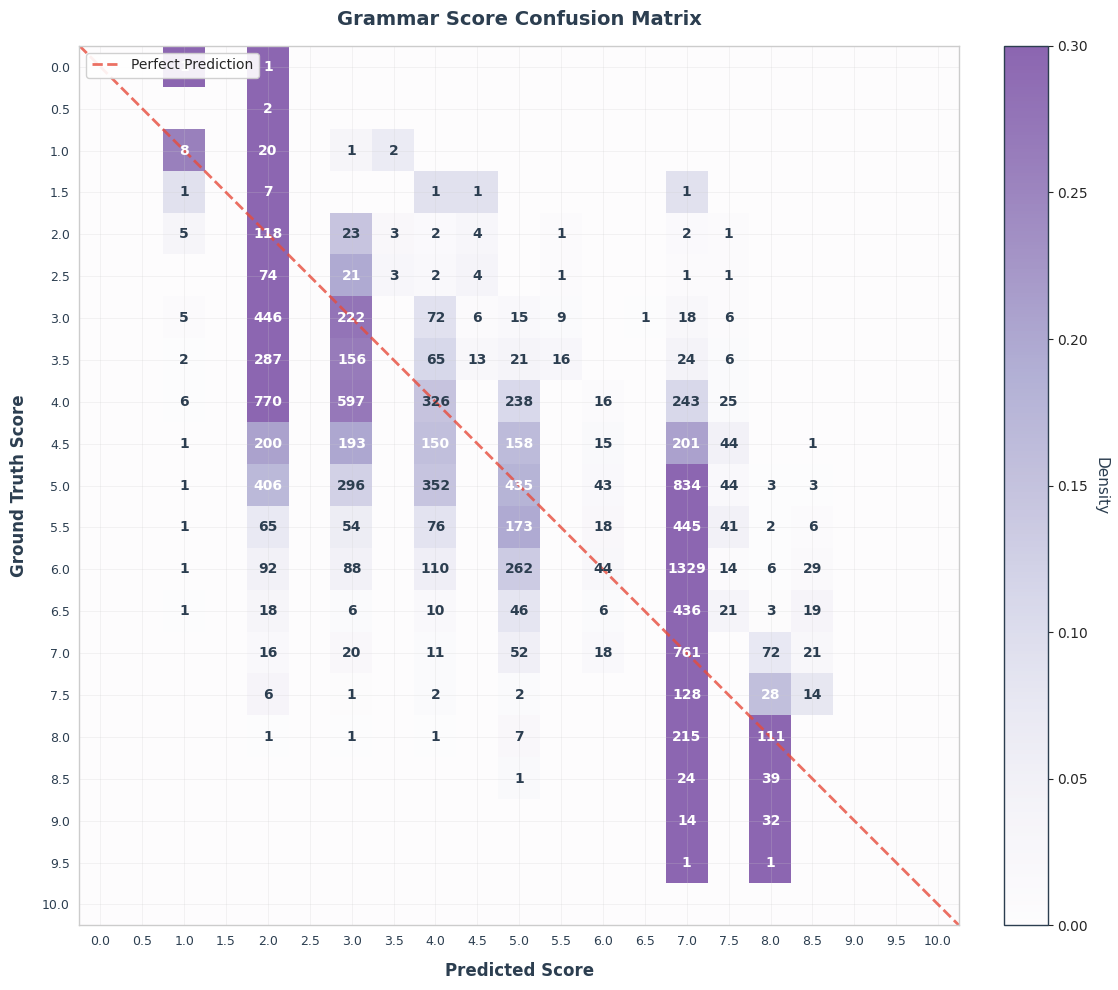

📊 Vocabulary Confusion Matrix


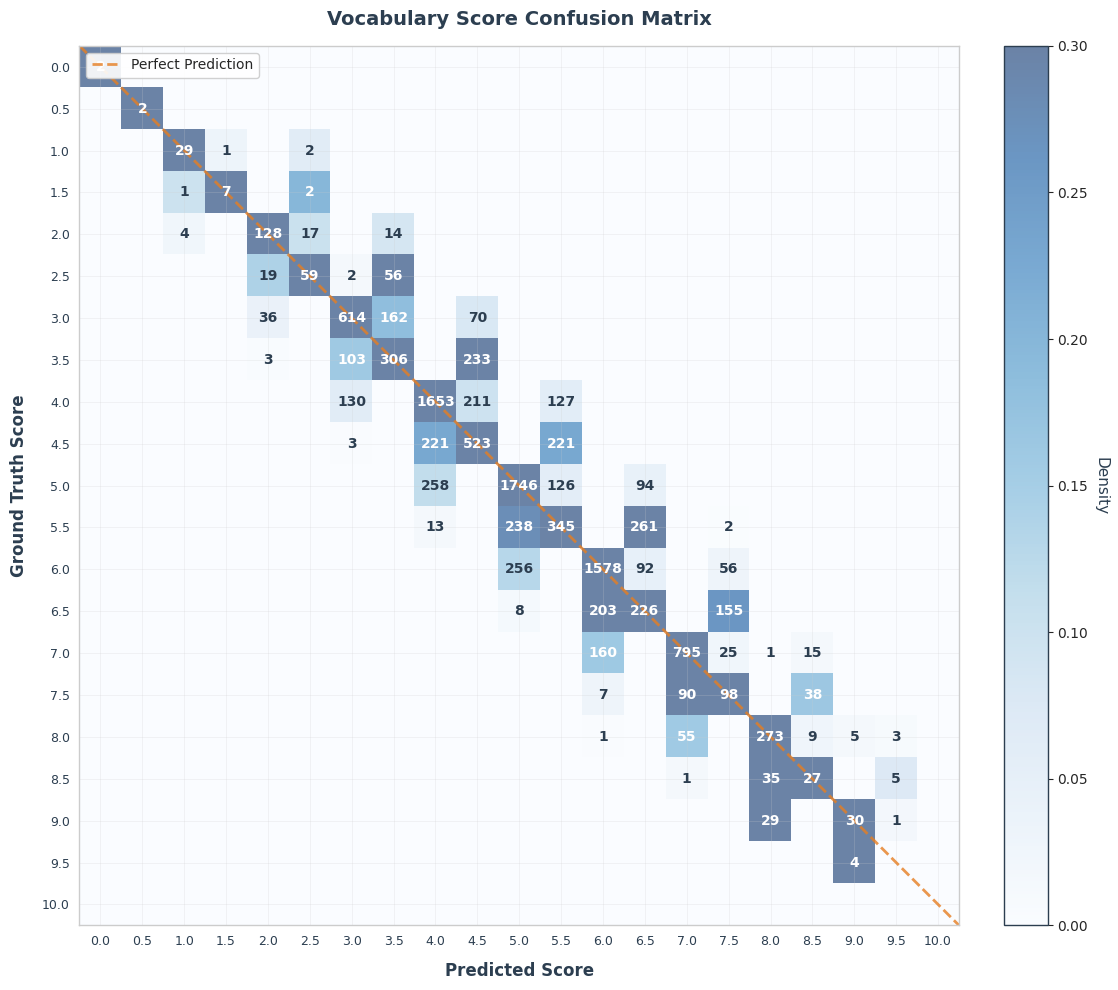

📊 Discourse Confusion Matrix


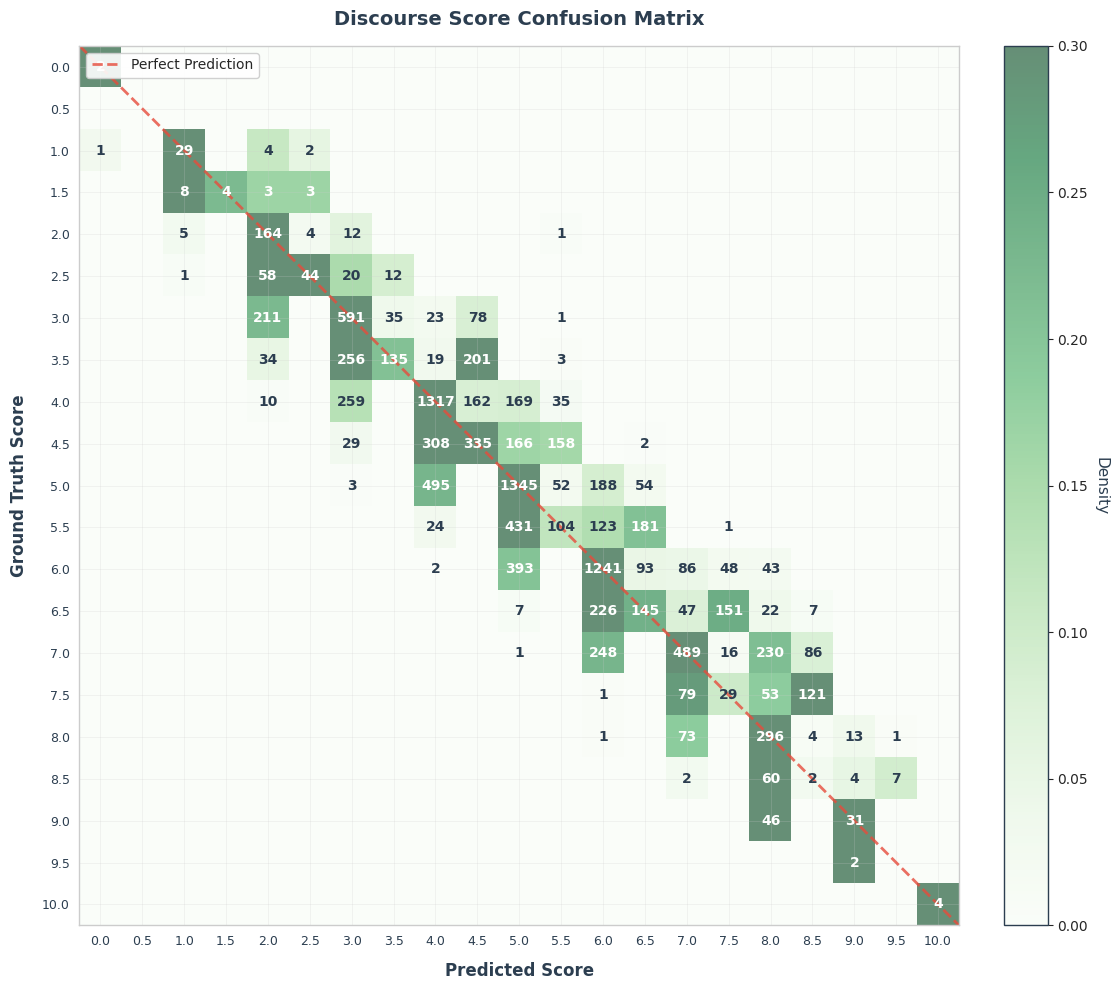

📊 Total Score Confusion Matrix


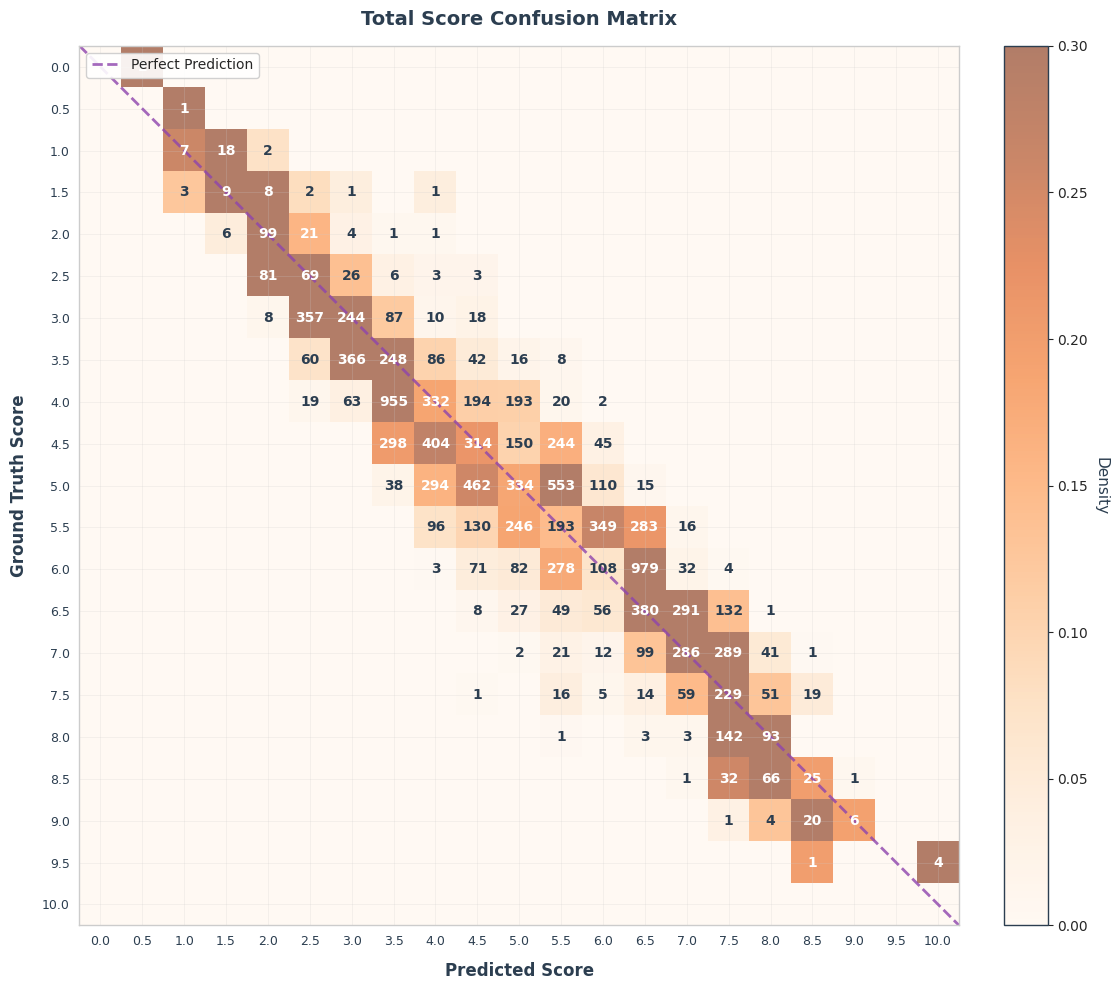

In [18]:
def plot_confusion_matrix(y_true, y_pred, title, figsize=(12, 10), color_style='soft'):
    """
    Clean, minimalist confusion matrix with only counts - no percentages.
    """
    # Round and convert
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    scores = np.arange(0, 10.5, 0.5)
    scores_str = [f"{x:.1f}" for x in scores]
    
    cm = confusion_matrix(y_true_str, y_pred_str, labels=scores_str)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    cm_norm = np.nan_to_num(cm_norm)
    
    # Create clean figure
    fig = plt.figure(figsize=figsize, facecolor='white')
    ax = plt.subplot(111, facecolor='white')
    
    # Choose color scheme - lighter and more elegant
    if color_style == 'soft':
        cmap = plt.cm.Purples
        diagonal_color = '#E74C3C'
        text_dark = '#2C3E50'
    elif color_style == 'ocean':
        cmap = plt.cm.Blues
        diagonal_color = '#E67E22'
        text_dark = '#2C3E50'
    elif color_style == 'mint':
        cmap = plt.cm.Greens
        diagonal_color = '#E74C3C'
        text_dark = '#2C3E50'
    elif color_style == 'sunset':
        cmap = plt.cm.Oranges
        diagonal_color = '#8E44AD'
        text_dark = '#2C3E50'
    elif color_style == 'minimal':
        cmap = plt.cm.Greys
        diagonal_color = '#3498DB'
        text_dark = '#2C3E50'
    else:
        cmap = plt.cm.Purples
        diagonal_color = '#E74C3C'
        text_dark = '#2C3E50'
    
    # Plot with very light colors
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=0.3, alpha=0.6)
    
    # Clean colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Density', rotation=-90, va="bottom", 
                       fontsize=11, color=text_dark)
    cbar.outline.set_linewidth(1)
    cbar.outline.set_edgecolor(text_dark)
    
    # Clean ticks
    tick_marks = np.arange(len(scores))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(scores, rotation=0, ha='center', fontsize=9, color=text_dark)
    ax.set_yticklabels(scores, fontsize=9, color=text_dark)
    
    # Add only count numbers - clean and simple
    for i in range(len(scores)):
        for j in range(len(scores)):
            if cm[i, j] > 0:
                # Only show count, no percentage
                count_text = f'{cm[i, j]}'
                
                # Choose text color based on background
                if cm_norm[i, j] > 0.15:
                    text_color = 'white'
                else:
                    text_color = text_dark
                
                ax.text(j, i, count_text, ha="center", va="center",
                       color=text_color, fontsize=10, fontweight='bold')
    
    # Simple diagonal line
    ax.plot([-.5, len(scores)-.5], [-.5, len(scores)-.5], 
            color=diagonal_color, linewidth=2, alpha=0.8, 
            linestyle='--', label='Perfect Prediction')
    
    # Clean labels
    ax.set_ylabel('Ground Truth Score', fontsize=12, fontweight='bold', 
                  labelpad=10, color=text_dark)
    ax.set_xlabel('Predicted Score', fontsize=12, fontweight='bold', 
                  labelpad=10, color=text_dark)
    ax.set_title(f'{title}', fontsize=14, fontweight='bold', 
                pad=15, color=text_dark)
    
    # Simple legend
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    
    # Clean spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

# ============================================================================
# CELL 6: Plot All Confusion Matrices - Clean Version (Count Only)
# ============================================================================

print("🎨 Available color styles:")
print("1. 'soft' - Light Purple (Recommended)")
print("2. 'ocean' - Light Blue") 
print("3. 'mint' - Light Green")
print("4. 'sunset' - Light Orange")
print("5. 'minimal' - Grayscale")
print()

# Grammar Confusion Matrix
print("📊 Grammar Confusion Matrix")
fig1 = plot_confusion_matrix(
    df_clean['GT Grammar'].values,
    df_clean['Pred Grammar'].values,
    'Grammar Score Confusion Matrix',
    color_style='soft'
)
plt.show()

# Vocabulary Confusion Matrix
print("📊 Vocabulary Confusion Matrix")
fig2 = plot_confusion_matrix(
    df_clean['GT Vocab'].values,
    df_clean['Pred Vocab'].values,
    'Vocabulary Score Confusion Matrix',
    color_style='ocean'
)
plt.show()

# Discourse Confusion Matrix
print("📊 Discourse Confusion Matrix")
fig3 = plot_confusion_matrix(
    df_clean['GT Discourse'].values,
    df_clean['Pred Discourse'].values,
    'Discourse Score Confusion Matrix',
    color_style='mint'
)
plt.show()

# Total Confusion Matrix
print("📊 Total Score Confusion Matrix")
fig4 = plot_confusion_matrix(
    df_clean['GT Total'].values,
    df_clean['Pred Total'].values,
    'Total Score Confusion Matrix',
    color_style='sunset'
)
plt.show()

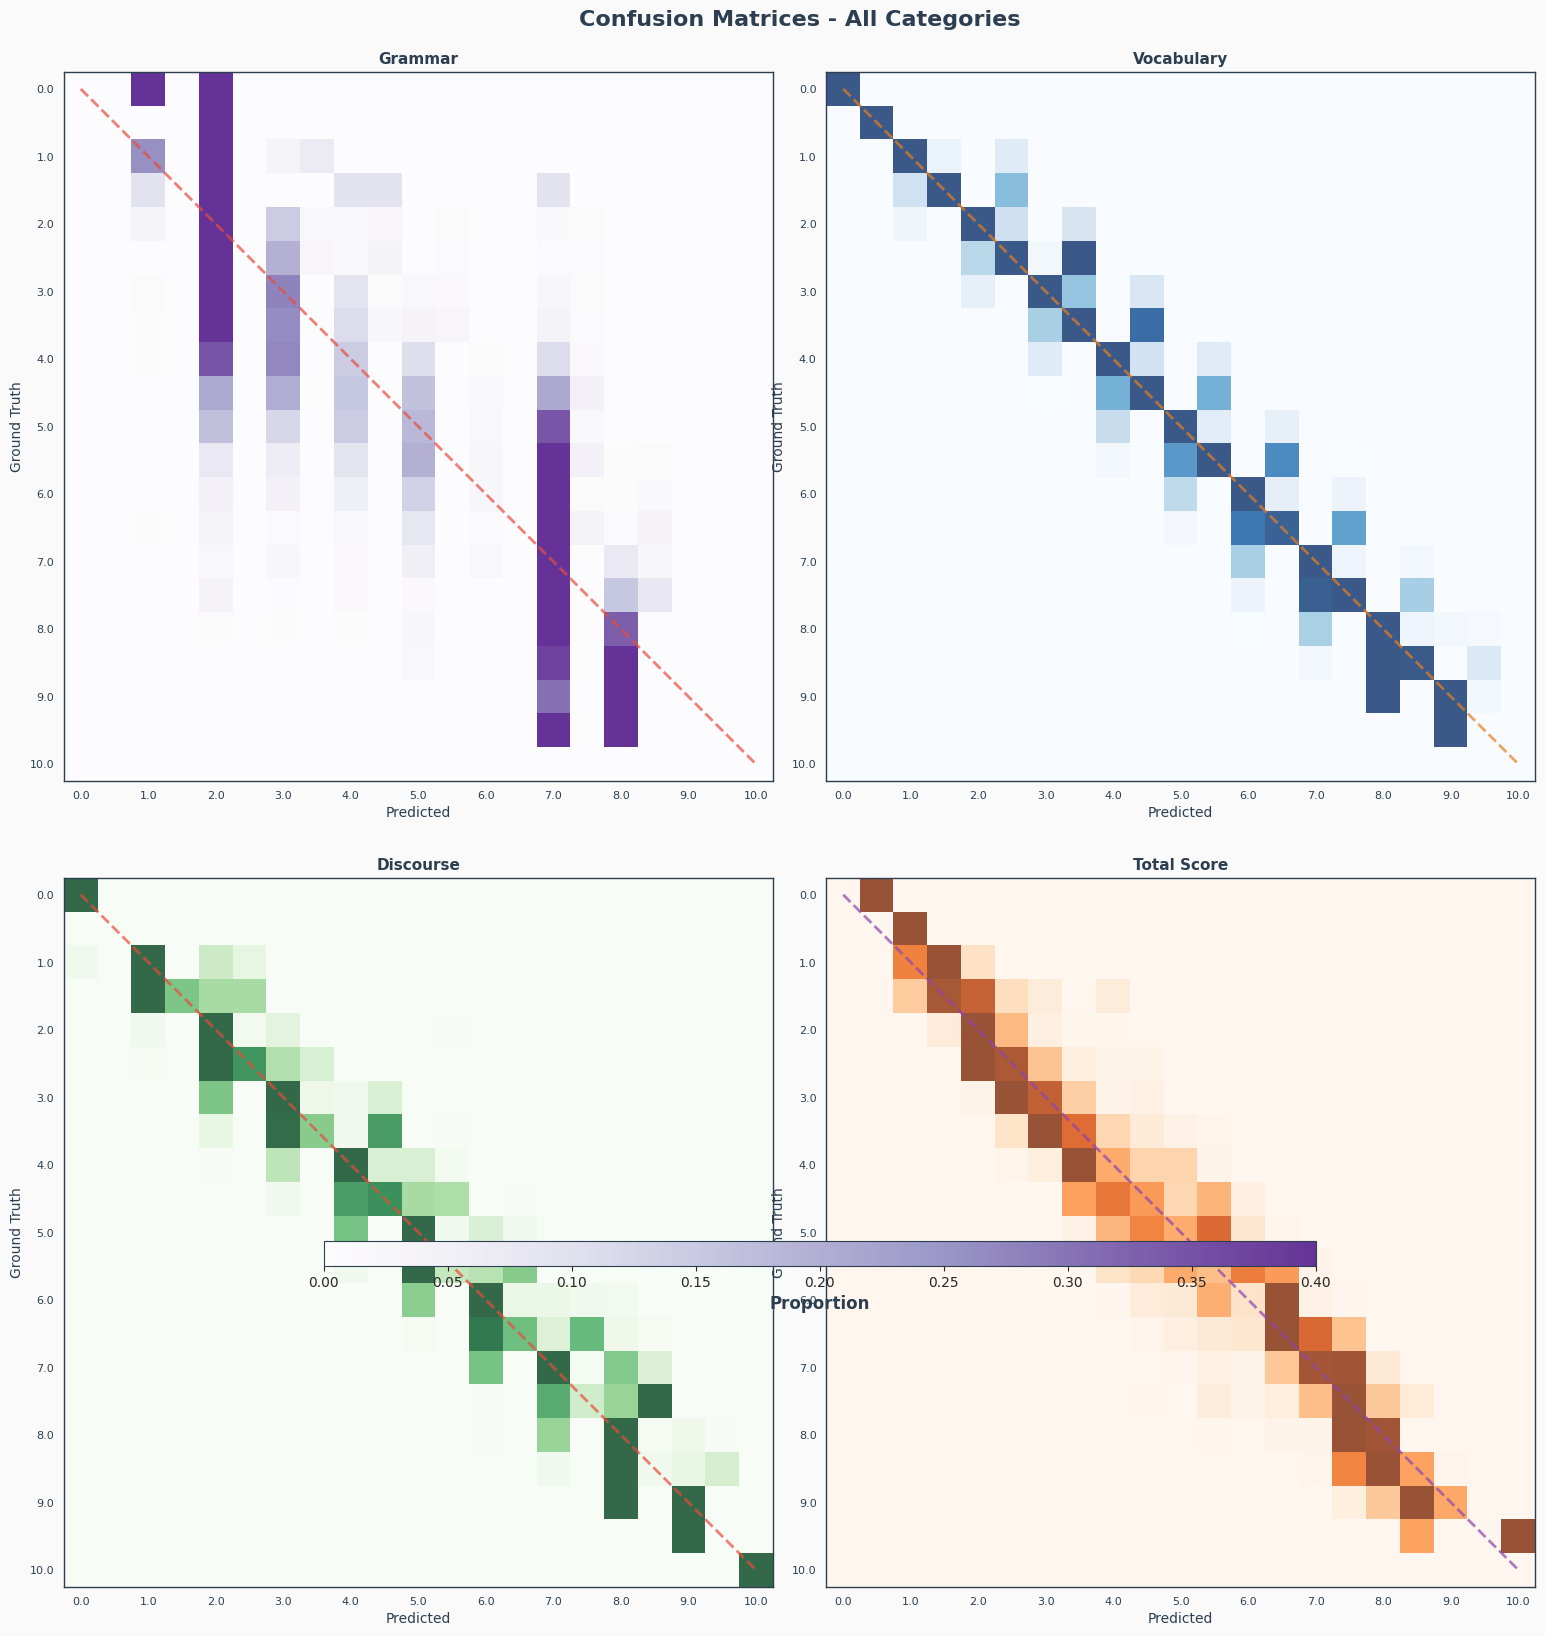

In [19]:
def plot_compact_confusion_matrix(y_true, y_pred, ax, title, color_style='soft'):
    """Plot compact confusion matrix on given axis with improved colors."""
    # Round to nearest 0.5
    y_true_rounded = np.round(y_true * 2) / 2
    y_pred_rounded = np.round(y_pred * 2) / 2
    
    # Convert to strings for categorical treatment
    y_true_str = [f"{x:.1f}" for x in y_true_rounded]
    y_pred_str = [f"{x:.1f}" for x in y_pred_rounded]
    
    # Get all possible scores
    possible_scores = np.arange(0, 10.5, 0.5)
    possible_scores_str = [f"{x:.1f}" for x in possible_scores]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true_str, y_pred_str, labels=possible_scores_str)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)
    
    # Choose colormap based on style
    if color_style == 'soft':
        cmap = plt.cm.Purples
        diagonal_color = '#E74C3C'
    elif color_style == 'ocean':
        cmap = plt.cm.Blues
        diagonal_color = '#E67E22'
    elif color_style == 'mint':
        cmap = plt.cm.Greens
        diagonal_color = '#E74C3C'
    elif color_style == 'sunset':
        cmap = plt.cm.Oranges
        diagonal_color = '#8E44AD'
    else:
        cmap = plt.cm.Purples
        diagonal_color = '#E74C3C'
    
    # Plot with reduced intensity
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap=cmap, 
                   vmin=0, vmax=0.4, alpha=0.8)
    
    # Set ticks (show every other tick to avoid crowding)
    tick_marks = np.arange(len(possible_scores))
    ax.set_xticks(tick_marks[::2])
    ax.set_yticks(tick_marks[::2])
    ax.set_xticklabels(possible_scores[::2], fontsize=8, color='#2C3E50')
    ax.set_yticklabels(possible_scores[::2], fontsize=8, color='#2C3E50')
    
    ax.set_ylabel('Ground Truth', fontsize=10, color='#2C3E50')
    ax.set_xlabel('Predicted', fontsize=10, color='#2C3E50')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#2C3E50')
    
    # Add diagonal line with softer color
    ax.plot([0, len(possible_scores)-1], [0, len(possible_scores)-1], 
            color=diagonal_color, linewidth=2, alpha=0.7, linestyle='--')
    
    # Style spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(1)
    
    return im

# Create 2x2 subplot with softer background
fig, axes = plt.subplots(2, 2, figsize=(16, 16), facecolor='#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

# Plot each category with different soft color styles
im1 = plot_compact_confusion_matrix(df_clean['GT Grammar'].values, 
                                     df_clean['Pred Grammar'].values,
                                     axes[0, 0], 'Grammar', 'soft')

im2 = plot_compact_confusion_matrix(df_clean['GT Vocab'].values,
                                     df_clean['Pred Vocab'].values,
                                     axes[0, 1], 'Vocabulary', 'ocean')

im3 = plot_compact_confusion_matrix(df_clean['GT Discourse'].values,
                                     df_clean['Pred Discourse'].values,
                                     axes[1, 0], 'Discourse', 'mint')

im4 = plot_compact_confusion_matrix(df_clean['GT Total'].values,
                                     df_clean['Pred Total'].values,
                                     axes[1, 1], 'Total Score', 'sunset')

# Add colorbar with better styling
cbar = fig.colorbar(im1, ax=axes, orientation='horizontal', 
                    pad=0.05, aspect=40, shrink=0.8)
cbar.set_label('Proportion', fontsize=12, color='#2C3E50', fontweight='bold')
cbar.outline.set_edgecolor('#2C3E50')

plt.suptitle('Confusion Matrices - All Categories', 
             fontsize=16, fontweight='bold', y=0.995, color='#2C3E50')
plt.tight_layout()
plt.show()

In [10]:
def detailed_error_analysis(gt_col, pred_col, category_name):
    """Create detailed error analysis for a category."""
    errors = abs(df_clean[pred_col] - df_clean[gt_col])
    
    stats = {
        'Category': category_name,
        'MAE': f"{errors.mean():.4f}",
        'Median Error': f"{errors.median():.4f}",
        'Std Error': f"{errors.std():.4f}",
        'Max Error': f"{errors.max():.4f}",
        'Exact (0)': f"{(errors == 0).sum()} ({(errors == 0).sum()/len(errors)*100:.1f}%)",
        'Within 0.5': f"{(errors <= 0.5).sum()} ({(errors <= 0.5).sum()/len(errors)*100:.1f}%)",
        'Within 1.0': f"{(errors <= 1.0).sum()} ({(errors <= 1.0).sum()/len(errors)*100:.1f}%)",
        'Above 1.0': f"{(errors > 1.0).sum()} ({(errors > 1.0).sum()/len(errors)*100:.1f}%)"
    }
    return stats

# Create detailed analysis
analysis_data = []
analysis_data.append(detailed_error_analysis('GT Grammar', 'Pred Grammar', 'Grammar'))
analysis_data.append(detailed_error_analysis('GT Vocab', 'Pred Vocab', 'Vocabulary'))
analysis_data.append(detailed_error_analysis('GT Discourse', 'Pred Discourse', 'Discourse'))
analysis_data.append(detailed_error_analysis('GT Total', 'Pred Total', 'Total'))

analysis_df = pd.DataFrame(analysis_data)

print("="*120)
print("DETAILED ERROR ANALYSIS")
print("="*120)
print(analysis_df.to_string(index=False))
print("="*120)

DETAILED ERROR ANALYSIS
  Category    MAE Median Error Std Error Max Error    Exact (0)    Within 0.5    Within 1.0    Above 1.0
   Grammar 1.2810       1.0000    0.9603    6.0000 2025 (16.4%)  3485 (28.3%)  7261 (58.9%) 5064 (41.1%)
Vocabulary 0.2690       0.0000    0.4368    2.0000 8441 (68.5%) 10001 (81.1%) 11906 (96.6%)   419 (3.4%)
 Discourse 0.4213       0.0000    0.4871    3.5000 6307 (51.2%)  8536 (69.3%) 11826 (96.0%)   499 (4.0%)
     Total 0.4936       0.3333    0.3578    2.6667 1470 (11.9%)  7553 (61.3%) 11500 (93.3%)   825 (6.7%)
